# Import libraries


In [ ]:
#%% importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#matplotlib inline

import datetime
import lightgbm as lgb
from scipy import stats
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
#from wordcloud import WordCloud
from collections import Counter
# from nltk.corpus import stopwords
# from nltk.util import ngrams
# stop = set(stopwords.words('english'))

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler



import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls

# from xgboost import XGBClassifier
from sklearn import model_selection
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
import tensorflow as tf
from sklearn import preprocessing
from tensorflow.keras import layers, models

import os
# https://www.kaggle.com/code/richardgg93/rnn-example
#https://www.kaggle.com/code/artgor/eda-feature-engineering-and-everything


# 2-Import Data


In [67]:
#%% import data
script_dir = os.getcwd()
file_path = os.path.join(script_dir, 'Cryptocurrency Prices by Date.csv')
df = pd.read_csv(file_path)

#convert Unix time ine #Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], unit='ms')

df['Date'] = df['Date'].dt.date # Extract date only (remove time if present)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

#find duplicated date for each currency and replace the price with mean price for that date
df = df.groupby(['Currency', 'Date']).agg({'Price': 'mean'}).reset_index()

#count the number of duplicated date for each currency
duplicated_counts = df.groupby(['Currency', 'Date']).size()
duplicated_counts = duplicated_counts[duplicated_counts > 1]
print("Number of duplicated date for each currency:")
print(duplicated_counts)




Number of duplicated date for each currency:
Series([], dtype: int64)


# 3-Plot Data


In [43]:
# %% -------------------- At first let's take 10 random currencies with minimum Price > threshold and plot them.
np.random.seed(40)  # For reproducibility
threshold=10
eligible_currencies = df.loc[df['Price'] < 1000000, 'Currency'].unique()
selected_currencies = np.random.choice(eligible_currencies, min(30, len(eligible_currencies)), replace=False)


data = []
for currency in selected_currencies:
    currency_df = df[df['Currency'] == currency]
    if not currency_df.empty:
        data.append(go.Scatter(
            x=currency_df['Date'],
            y=currency_df['Price'],
            mode='lines',
            name=currency
        ))

layout = go.Layout(
    title=f"Price of {len(selected_currencies)} random assets",
    xaxis=dict(title='Date'),
    yaxis=dict(title='Price (USD)'),
    legend=dict(orientation="h")
)
py.iplot(dict(data=data, layout=layout), filename='basic-line')
#Currencies are sampled randomly, but you should see that some currencies started trading later 

#plot to 10 currencies with highest price at the end of the period
latest_prices = df.groupby('Currency')['Price'].last()
top_currencies = latest_prices.sort_values(ascending=False).head(10).index
data = []
for currency in top_currencies:
    currency_df = df[df['Currency'] == currency]
    if not currency_df.empty:
        data.append(go.Scatter(
            x=currency_df['Date'],
            y=currency_df['Price'],
            mode='lines',
            name=currency
        ))
layout = go.Layout(
    title=f"Price of top 10 assets with highest price at the end of the period",
    xaxis=dict(title='Date'),
    yaxis=dict(title='Price (USD)'),
)
py.iplot(dict(data=data, layout=layout), filename='basic-line')


# 4- Clean up data from artifacts


In [68]:
# delete the top 3 currencies with highest price at the end of the period and plot the rest of the currencies
n_currencies = df['Currency'].nunique()
latest_prices = df.groupby('Currency')['Price'].last()
top_currencies = latest_prices.sort_values(ascending=False).head(3).index
df = df[~df['Currency'].isin(top_currencies)]

#delete  currencies with price <0.01 at the end date of the period
df = df.sort_values(['Currency', 'Date'])
last_prices = (
    df
    .groupby('Currency')
    .last()              # last row per currency (after sorting)
    .reset_index()
)
valid_currencies = last_prices[last_prices['Price'] >= 0.01]['Currency']
df = df[df['Currency'].isin(valid_currencies)]

n_currencies_after_deletion = df['Currency'].nunique()
print(f"Number of deleted currencies after deleting price <0.01: {n_currencies-n_currencies_after_deletion}")

#delete currencies that started trading after 2014-01-01
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Currency', 'Date'])
first_dates = (
    df
    .groupby('Currency')['Date']
    .min()
    .reset_index(name='start_date')
)

cutoff = pd.Timestamp('2014-01-01')
valid_currencies = first_dates[first_dates['start_date'] <= cutoff]['Currency']
df = df[df['Currency'].isin(valid_currencies)]
#print the number of deleted currencies after deleting those that started trading after 2015-01-01
n_currencies_after_deletion = df['Currency'].nunique()
print(f"Number of deleted currencies after deleting those that started trading after 2014-01-01: {n_currencies-n_currencies_after_deletion}")
print(f"Number of remaining currencies after cleaning: {df['Currency'].nunique()}")


#plot top 10 currencies with highest price at the end of the period in df
latest_prices_filtered = df.groupby('Currency')['Price'].last()    
top_currencies_filtered = latest_prices_filtered.sort_values(ascending=False).head(10).index
data = []
for currency in top_currencies_filtered:
    currency_df = df[df['Currency'] == currency]
    if not currency_df.empty:
        data.append(go.Scatter(
            x=currency_df['Date'],
            y=currency_df['Price'],
            mode='lines',
            name=currency
        ))
layout = go.Layout(
    title=f"Price of top 10 assets with highest price at the end of the period after removing top 3",
    xaxis=dict(title='Date'),
    yaxis=dict(title='Price (USD)'),
)
py.iplot(dict(data=data, layout=layout), filename='basic-line')

Number of deleted currencies after deleting price <0.01: 353
Number of deleted currencies after deleting those that started trading after 2014-01-01: 1472
Number of remaining currencies after cleaning: 43


# 5- Create Monthly Data


In [69]:
df_m = (
    df
    .set_index('Date')
    .groupby('Currency')['Price']
    .resample('ME')                # monthly frequency
    .mean()                      # mean price per month
    .reset_index()
)

monthly_ohlc = (
    df
    .set_index('Date')
    .groupby('Currency')['Price']
    .resample('ME')
    .agg(['first', 'last', 'std', 'mean'])   # first = open, last = close, std = standard deviation, mean = mean price
    .reset_index()
    .rename(columns={
        'first': 'open price',
        'last': 'close price',
        'std': 'SD',
        'mean': 'mean price'

    })
)
df_m = df_m.merge(
    monthly_ohlc,
    on=['Currency', 'Date'],
    how='left'
)
df_m['month_diff'] = df_m['close price'] - df_m['open price']
df_m['month_diff_pct'] = df_m['month_diff'] / df_m['open price'] * 100
#print the top 10 months with highest % change of price change within a month
print("Top 10 months by % change of price change within a month:")
print(df_m.sort_values('month_diff_pct', ascending=False).head(10)[['Currency', 'Date', 'open price', 'close price', 'month_diff_pct']])

#Top 10 months by %change of price change within a month
top10_months = df_m.sort_values('month_diff_pct', ascending=False).head(10)
#include the currency name in the hover text
trace = go.Scatter(
    x = top10_months['Date'].dt.strftime(date_format='%Y-%m-%d').values,
    y = top10_months['month_diff_pct'].values,
    mode='markers',
    marker=dict(
        size = top10_months['month_diff_pct'].values*0.001,  # Adjust the size multiplier as needed
        color = top10_months['month_diff_pct'].values,
        colorscale='Portland',
        showscale=True
    ),
    text = top10_months['Date'].dt.strftime(date_format='%Y-%m-%d').values + '<br>' + top10_months['Currency'].values
    #text = f"Maximum price drop: {top10_months['SD'].values}"
    #top10_months['Date'].dt.strftime(date_format='%Y-%m-%d').values
)
data = [trace]

layout= go.Layout(
    autosize= True,
    title= 'Top 10 months by % price change within a month',
    hovermode= 'closest',
    yaxis=dict(
        title= '% Price Change',
        ticklen= 5,
        gridwidth= 2,
    ),
    showlegend= False
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig,filename='scatter2010')
# https://www.kaggle.com/code/richardgg93/rnn-example


Top 10 months by % change of price change within a month:
         Currency       Date  open price  close price  month_diff_pct
1881        quark 2013-11-30    0.000148     0.048587    32814.628694
118        bitbar 2013-11-30    0.716590   170.223000    23654.587700
1275     megacoin 2013-11-30    0.013466     2.602430    19226.506060
52       anoncoin 2017-11-30    0.006572     0.422589     6330.368074
891      freicoin 2013-11-30    0.006310     0.338475     5264.325630
1770  phoenixcoin 2013-11-30    0.000617     0.030578     4854.221490
4        anoncoin 2013-11-30    0.223471     8.698500     3792.451370
498   digitalcoin 2013-11-30    0.012433     0.437572     3419.326974
666      fastcoin 2013-11-30    0.000642     0.016940     2538.495386
1392     namecoin 2013-11-30    0.451415    10.802700     2293.075108


In [70]:
# %% -------------------- Take bitcoin currencies  plot it.
btc_df= df[df['Currency'] == 'bitcoin'].copy()
btc_df['YearMonth'] = btc_df['Date'].dt.to_period('M')
btc_df_m=df_m[df_m['Currency'] == 'bitcoin'].copy()

data=[]
data.append(go.Scatter(
            x=btc_df['Date'],
            y=btc_df['Price'],
            mode='lines',
            name="bitcoin"
        ))
layout = go.Layout(
    title="Bitcoin Price",
    xaxis=dict(title='Date'),
    yaxis=dict(title='Price (USD)'),
    legend=dict(orientation="h")
)
py.iplot(dict(data=data, layout=layout), filename='basic-line')

#Now let's take a look at bicoin monthly percentile.
data = []
for i in [0.05,  0.25, 0.5, 0.75, 0.95]:
    price_df = btc_df.groupby('YearMonth')['Price'].quantile(i).reset_index()

    data.append(go.Scatter(
        x = btc_df.groupby('YearMonth').first()['Date'].dt.strftime(date_format='%Y-%m').values,
        y = price_df['Price'].values,
        name = f'{i} quantile'
    ))
layout = go.Layout(dict(title = "Trends of Bitcoin by quantiles",
                  xaxis = dict(title = 'Month'),
                  yaxis = dict(title = 'Price (USD)'),
                  ),legend=dict(
                orientation="h"),)
py.iplot(dict(data=data, layout=layout), filename='basic-line')

# 6-Pairwise Regression


Correlation between bitcoin and top 5 currencies:
Currency
litecoin      0.917258
diamond       0.902594
florincoin    0.852275
goldcoin      0.836159
sexcoin       0.775526
dtype: float64


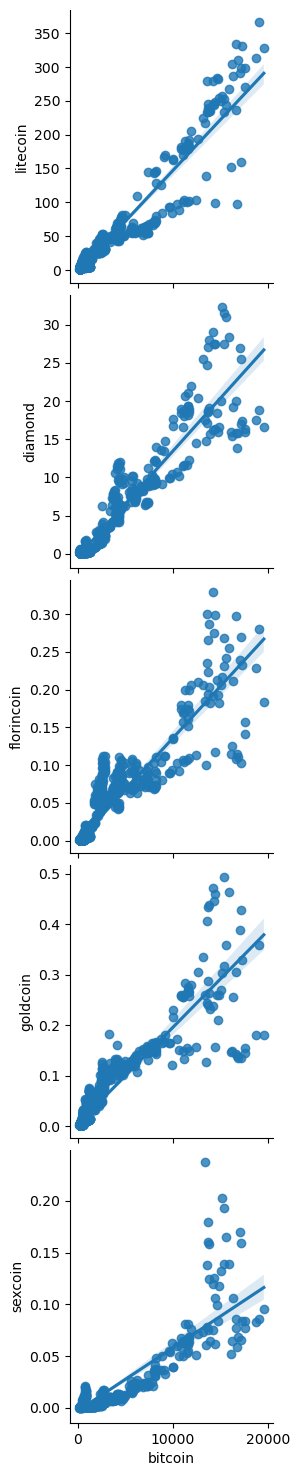

In [114]:
#conduct a pairwise regression analysis between the price of bitcoin and other currencies with in a month starting 2014-01-01, and plot the regression line for each month. We will use the monthly mean price for this analysis.
#use sns.pairplot library for regression analysis

df = df[df['Date'] >= '2014-01-01']
# ensure datetime
df['Date'] = pd.to_datetime(df['Date'])




# choose a subset (example: top 5 or specific ones)
# selected_cols = ['bitcoin', 'ethereum', 'litecoin', 'ripple', 'cardano']
#select top 5 currencies with highest price at the end of the period

df = df.sort_values(['Currency', 'Date'])
#get the list of currencies in the same order as in df_wide

selected_cols= df.columns[df.columns != 'bitcoin']  # all except bitcoin


#calcualte the correlation between bitcoin and other currencies in the same period
df_wide = df.pivot_table(
    index='Date',
    columns='Currency',
    values='Price',
    aggfunc='mean'
)
df_wide = df_wide.sort_index()
r2 = (
    df_wide
    .corrwith(df_wide['bitcoin'])      # correlation with bitcoin
    .drop('bitcoin')    # remove self-correlation
    .pow(2)             # R²
)
top5_r2 = r2.sort_values(ascending=False).head(5)

print("Correlation between bitcoin and top 5 currencies:")
print(top5_r2)

top5 = list(top5_r2.index)
selected_cols = ['bitcoin'] + top5
df_plot = df_wide[selected_cols].dropna()
sns.pairplot(
    df_plot,
    x_vars=['bitcoin'],
    y_vars=top5,
    kind='reg',
    height=3
)
plt.show()

#plot top 5 currencies with highest correlation with bitcoin over time
data=[]
for i in selected_cols:  
    data.append(go.Scatter(
        x = df[df["Currency"] == i]['Date'].dt.strftime(date_format='%Y-%m-%d').values,
        y = df[df["Currency"] == i]['Price'].values/df[df["Currency"] == i]['Price'].max(),  # Normalize price for better comparison
        name = f'{i}'
    ))
layout = go.Layout(dict(title = "Normalized prices of Bitcoin and top 5 correlated currencies",
                  xaxis = dict(title = 'Date'),
                  yaxis = dict(title = 'Price (USD)'),
                  ),legend=dict(
                orientation="h"),)
py.iplot(dict(data=data, layout=layout), filename='basic-line')

# 7- Train a simeple RNN model


IndexError: list index out of range

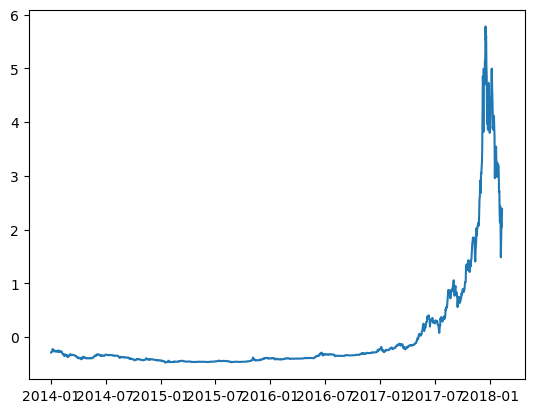

In [ ]:
#df_final = df_wide with columns 'Date', 'bitcoin','litecoin','diamond' and drop rows with NA values
from sklearn import preprocessing

# df_wide['Date']=df_wide['Date'].dt.to_pydatetime()  # Convert to datetime if not already

df_final = df_wide[['bitcoin','litecoin','diamond']].dropna()
aux = df_final.copy()

# features = ["bitcoin","litecoin"]
features = ["bitcoin"]
target = ["bitcoin"]

# SCALE THE VARIABLES TO HAVE MEAN 0 AND STD DEV 1
# OTHERWISE IT TAKES PLENTY OF TIME TO TRAIN AND IT STARTS WITH THE VALUES CLOSER TO 0
scaler_features = preprocessing.StandardScaler().fit(aux[features])
scaler_target = preprocessing.StandardScaler().fit(aux[target].values.reshape(-1,1))
aux[features] = scaler_features.transform(aux[features])  #scale the features to have mean 0 and std dev 1
# aux[target] = scaler_target.transform(aux[target].values.reshape(-1,1))  #scale the target to have mean 0 and std dev 1
plt.plot(aux.index, aux[features[0]])
plt.plot(aux.index, aux[features[1]])
plt.show()

# DEFINE THE MODEL
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.LSTM(32, unroll=True, return_sequences=True))
model.add(tf.keras.layers.LSTM(16, unroll=True))
model.add(tf.keras.layers.Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')






# 8 Train the RNN


In [199]:
# SPLIT INTO TRAIN AND TEST (UP TO 2016 TRAIN, LATER TEST)
train = aux[aux.index < np.datetime64('2017-01-01')]
test = aux[(aux.index >= np.datetime64('2017-01-01')) & (aux.index < np.datetime64('2018-01-01'))]

# DEFINE THE PERIOD OF TIME TO LOOK BACK FOR PREDICTION - 60 days look back and 3 days prediction
PERIOD = 60

# Preprocess train data
train_X=[]
train_y=[]
train_times=[]
for i in range(PERIOD, train.shape[0]):
    X = train.iloc[i-PERIOD:i][features].values
    y = train.iloc[i][target].values
    time = train.index[i]
    train_X.append(X)
    train_y.append(y)
    train_times.append(time)
train_X = np.array(train_X)
train_y = np.array(train_y)

# reshape input to be [samples, time steps, features]
train_X = np.reshape(train_X, (train_X.shape[0], PERIOD, len(features)))

# Preprocess test data
test_X=[]
test_y=[]
test_times=[]
for i in range(PERIOD, test.shape[0]):
    X = test.iloc[i-PERIOD:i][features].values
    y = test.iloc[i][target].values
    time = test.index[i]
    test_X.append(X)
    test_y.append(y)
    test_times.append(time)
test_X = np.array(test_X)
test_y = np.array(test_y)
# reshape input to be [samples, time steps, features]
test_X = np.reshape(test_X, (test_X.shape[0], PERIOD, len(features)))

# TRAIN THE MODEL, add early stopping callback to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=150, restore_best_weights=True)
model.fit(train_X, train_y, batch_size=5, epochs=200, verbose=1, shuffle=False, callbacks=[early_stopping])
model.summary()

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.8019e-04
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.2803e-04
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.0939e-04
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0012
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0012
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0011
Epoch 7/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0010
Epoch 8/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.6793e-04
Epoch 9/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 9.2725e-04
Epoch 10/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 9.0172e-04
Epoch 11/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.8141e-04
Epoch 12/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 8.6461e-04
Epoch 13/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.4959e-04
Epoch 14/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.3825e-04
Epo

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_47 (LSTM)                  │ (None, 60, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_48 (LSTM)                  │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,517 (87.96 KB)

 Trainable params: 7,505 (29.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,012 (58.64 KB)

# 9 Make Prediction


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
MAE: 1299.1894418017578
RMSE: 2858.9294269735155


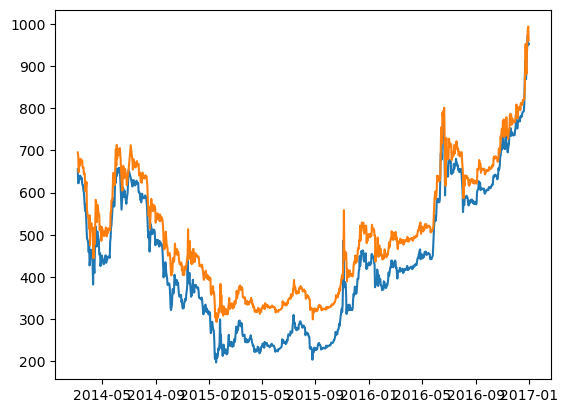

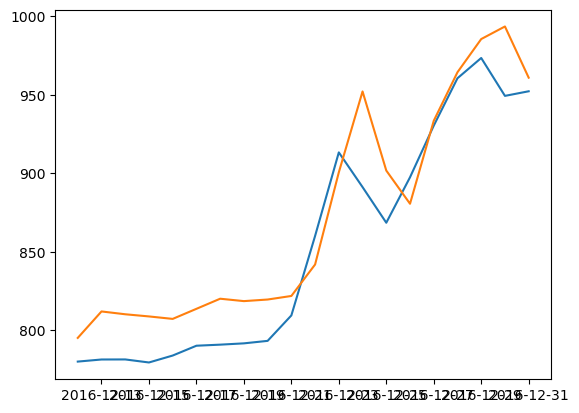

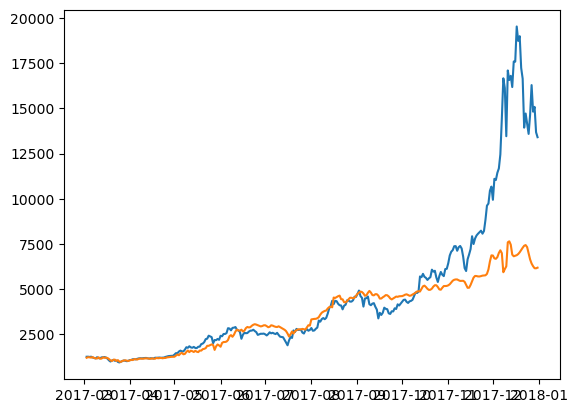

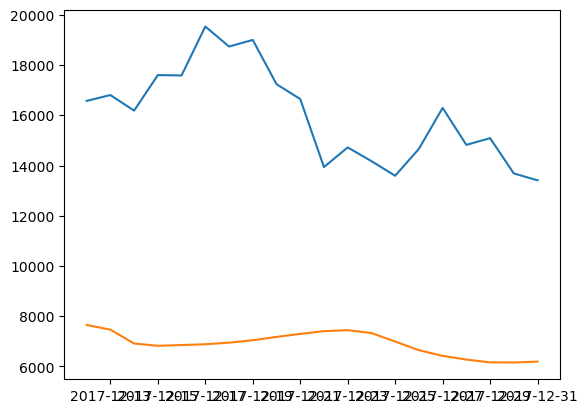

In [ ]:
# MAKE PREDICTIONS
train_preds = model.predict(train_X)
if train_preds.ndim == 3:
    train_preds = train_preds[:, -1, :]
trainPredictions = scaler_target.inverse_transform(train_preds)

# build the same sequence windows for test prediction that were used in training
X_test = []
y_test = []
for i in range(PERIOD, test_scaled.shape[0]):
    X_test.append(test_scaled.iloc[i-PERIOD:i][selected_features].values)
    y_test.append(test.iloc[i][target].values)
X_test = np.array(X_test)
y_test = np.array(y_test)
if X_test.ndim == 3 and X_test.shape[-1] == 1:
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
if y_test.ndim == 3:
    y_test = y_test.reshape(y_test.shape[0], -1)

testPredictions = best_model.predict(X_test)

# scores
print("MAE:", mean_absolute_error(y_test, testPredictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, testPredictions)))

# plots
plt.plot(train_times, scaler_target.inverse_transform(train_y))
plt.plot(train_times, trainPredictions)
plt.show()
plt.plot(train_times[-20:], scaler_target.inverse_transform(train_y[-20:]))
plt.plot(train_times[-20:], trainPredictions[-20:])
plt.show()
plt.plot(test_times, y_test)
plt.plot(test_times, testPredictions)
plt.show()
plt.plot(test_times[-20:], y_test[-20:])
plt.plot(test_times[-20:], testPredictions[-20:])
plt.show()

# 10 apply Optuna


In [ ]:
import optuna
import tensorflow as tf
import numpy as np
import pandas as pd
from optuna.integration import TFKerasPruningCallback
from sklearn.preprocessing import StandardScaler

df_final = df_wide[['bitcoin','litecoin','diamond']].dropna()
aux = df_final.copy()
# -----------------------------
# CONFIG
# -----------------------------
PERIOD = 60
all_features = ['bitcoin']  # <-- fix names here

# -----------------------------
# SPLIT DATA
# -----------------------------
train = aux[aux.index < np.datetime64('2017-01-01')].copy()
test = aux[(aux.index >= np.datetime64('2017-01-01')) & 
           (aux.index < np.datetime64('2018-01-01'))].copy()


def objective(trial):
    # -----------------------------
    # Hyperparameters to tune
    # -----------------------------
    n_units_1 = trial.suggest_int('n_units_1', 16, 64)
    n_units_2 = trial.suggest_int('n_units_2', 32 128)
    dropout = trial.suggest_float('dropout', 0.0, 0.005)
    batch_size = trial.suggest_categorical('batch_size', [4, 8])
    learning_rate = trial.suggest_float('lr', 1e-5, 1e-2, log=True)

    # -----------------------------
    # Feature combinations (controlled search space)
    # -----------------------------
    feature_sets = [
        tuple([all_features[0]]),# feature[0]=bitcoin
        # tuple([all_features[0], all_features[1]]) # feature[0,1]=bitcoin,litecoin
    ]
    selected_features = list(
        trial.suggest_categorical("feature_set", feature_sets)
    )
    trial.set_user_attr("features", selected_features)
    # avoid empty feature set
    if len(selected_features) == 0:
        return float('inf')
    # -----------------------------
    # Scale features (VERY IMPORTANT)
    # -----------------------------
    scaler = StandardScaler()
    train_scaled = train.copy()
    test_scaled = test.copy()

    train_scaled[selected_features] = scaler.fit_transform(train[selected_features])
    test_scaled[selected_features] = scaler.transform(test[selected_features])

    # -----------------------------
    # Build dataset (reuse your logic)
    # -----------------------------
    def build_dataset(data):
        X_list, y_list = [], []
        for i in range(PERIOD, data.shape[0]):
            X = data.iloc[i-PERIOD:i][selected_features].values
            y = data.iloc[i][target].values
            X_list.append(X)
            y_list.append(y)
        return np.array(X_list), np.array(y_list)

    X_train, y_train = build_dataset(train)
    X_val, y_val = build_dataset(test)

    # reshape
    X_train = X_train.reshape((X_train.shape[0], PERIOD, len(selected_features)))
    X_val = X_val.reshape((X_val.shape[0], PERIOD, len(selected_features)))

   
    # -----------------------------
    # Model (2-layer LSTM)
    # -----------------------------
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(
            n_units_1,
            return_sequences=True,
            input_shape=(PERIOD, len(selected_features)),
            dropout=dropout
        ),
        tf.keras.layers.LSTM(
            n_units_2,
            return_sequences=False,
            dropout=dropout
        ),
        tf.keras.layers.Dense(len(target))
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse'
    )
    # -----------------------------
    # Callbacks (EARLY STOP + PRUNING)
    # -----------------------------
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=50,
        restore_best_weights=True
    )
    pruning_callback = TFKerasPruningCallback(trial, monitor='val_loss')
    
    # -----------------------------
    # Train
    # -----------------------------
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,                 # upper bound (Optuna will stop early)
        batch_size=batch_size,
        verbose=0,
        shuffle=False,
        callbacks=[early_stopping, pruning_callback]
    )

    # -----------------------------
    # Objective metric
    # -----------------------------
    val_loss = min(history.history['val_loss'])
    return val_loss

In [216]:
# Run Optun
import optuna
study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,   # don't prune early trials
        n_warmup_steps=10     # wait for some epochs
    )
)

study.optimize(objective, n_trials=50)
# -----------------------------
# RESULTS
# -----------------------------
print("Best params:")
print(study.best_params)

print("Best loss:")
print(study.best_value)


[I 2026-04-06 13:53:55,304] A new study created in memory with name: no-name-0868bb84-e449-4f22-b6b0-d38b28f1322d
c:\ProgramData\anaconda3\lib\site-packages\optuna\distributions.py:502: UserWarning:

Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('bitcoin',) which is of type tuple.

c:\ProgramData\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.

[I 2026-04-06 13:59:29,225] Trial 0 finished with value: 36479392.0 and parameters: {'n_units_1': 96, 'n_units_2': 116, 'dropout': 0.0013612585616669343, 'batch_size': 4, 'lr': 6.822918314814804e-05, 'feature_set': ('bitcoin',)}. Best is trial 0 with value: 36479392.0.
c:\ProgramData\anaconda3\lib\site-packages\optuna\distributions.py:502: UserWarning:

Choices for a cat

KeyboardInterrupt: 

# 11- Make Prediction with Best model


Selected features: ['bitcoin', 'litecoin']


c:\ProgramData\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


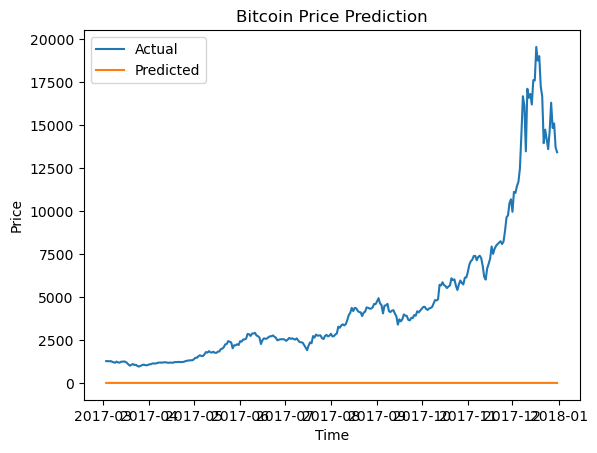

In [212]:
#Make predictions with the best trial
best_trial = study.best_trial
best_params = best_trial.params
selected_features = best_trial.user_attrs["features"]
print(f"Selected features: {selected_features}")

# Rebuild the best model with the selected features and hyperparameters
def build_best_model(params, features):
    n_units_1 = params['n_units_1']
    n_units_2 = params['n_units_2']
    dropout = params['dropout']
    learning_rate = params['lr']

    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(
            n_units_1,
            return_sequences=True,
            input_shape=(PERIOD, len(features)),
            dropout=dropout
        ),
        tf.keras.layers.LSTM(
            n_units_2,
            return_sequences=False,
            dropout=dropout
        ),
        tf.keras.layers.Dense(len(target))
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse'
    )
    return model
# Scale the data using the same logic as in the objective function
scaler = StandardScaler()
train_scaled = train.copy()
test_scaled = test.copy()
train_scaled[selected_features] = scaler.fit_transform(train[selected_features])

# Make Predictions with the best model
best_model = build_best_model(best_params, selected_features)
test_scaled[selected_features] = scaler.transform(test[selected_features])

# Create sequence windows to match the model input shape
X_test = []
y_test = []
for i in range(PERIOD, test_scaled.shape[0]):
    X_test.append(test_scaled.iloc[i-PERIOD:i][selected_features].values)
    y_test.append(test.iloc[i][target].values)
X_test = np.array(X_test)
y_test = np.array(y_test)

predictions = best_model.predict(X_test)

# plot the predictions vs actual values for the test set
plt.plot(test.index[PERIOD:], y_test, label='Actual')
plt.plot(test.index[PERIOD:], predictions, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Bitcoin Price Prediction')
plt.legend()
plt.show()



# 12 Create Many to Many Model


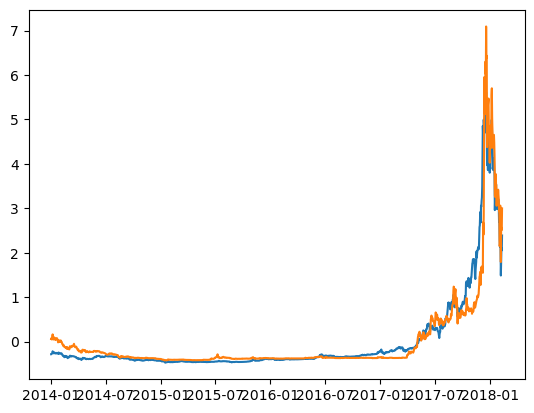

Model: "sequential_86"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_173 (LSTM)                 │ (None, 128)            │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_174 (LSTM)                 │ (None, 60, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 60, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,297 (778.50 KB)

 Trainable params: 199,297 (778.50 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_173 (LSTM)                 │ (None, 128)            │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_174 (LSTM)                 │ (None, 60, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 60, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 597,893 (2.28 MB)

 Trainable params: 199,297 (778.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 398,596 (1.52 MB)

In [ ]:

df_final = df_wide[['bitcoin','litecoin','diamond']].dropna()
aux = df_final.copy()
# SPLIT INTO TRAIN AND TEST (UP TO 2016 TRAIN, LATER TEST)
train = aux[aux.index < np.datetime64('2017-01-01')]
test = aux[(aux.index >= np.datetime64('2017-01-01')) & (aux.index < np.datetime64('2018-01-01'))]

features = ["bitcoin","litecoin","diamond"]
target = ["bitcoin"]

# DEFINE THE PERIOD OF TIME TO LOOK BACK FOR PREDICTION - 60 days look back and 3 days prediction
PERIOD = 60
#Scale features to have mean 0 and std dev 1, otherwise it takes plenty of time to train and it starts with the values closer to 0
scaler_features = preprocessing.StandardScaler().fit(aux[features])
scaler_target = preprocessing.StandardScaler().fit(aux[target].values.reshape(-1,1))
aux[features] = scaler_features.transform(aux[features])  #scale the features to have mean 0 and std dev 1

plt.plot(aux.index, aux[features[0]])
plt.plot(aux.index, aux[features[1]])
plt.show()

# Preprocess train data
train_X=[]
train_y=[]
train_times=[]
for i in range(PERIOD, train.shape[0]):
    X = train.iloc[i-PERIOD:i][features].values
    y = train.iloc[i][target].values
    time = train.index[i]
    train_X.append(X)
    train_y.append(y)
    train_times.append(time)
train_X = np.array(train_X)
train_y = np.array(train_y)

# reshape input to be [samples, time steps, features]
train_X = np.reshape(train_X, (train_X.shape[0], PERIOD, len(features)))

# Preprocess test data
test_X=[]
test_y=[]
test_times=[]
for i in range(PERIOD, test.shape[0]):
    X = test.iloc[i-PERIOD:i][features].values
    y = test.iloc[i][target].values
    time = test.index[i]
    test_X.append(X)
    test_y.append(y)
    test_times.append(time)
test_X = np.array(test_X)
test_y = np.array(test_y)
# reshape input to be [samples, time steps, features]
test_X = np.reshape(test_X, (test_X.shape[0], PERIOD, len(features)))


# DEFINE THE Many-To-Many LSTM MODEL
model_M2M = models.Sequential([
    layers.Input(shape=[PERIOD, len(features)]),
    #Encoder
    layers.LSTM(128, unroll=True),
    #Repeat context for each period
    layers.RepeatVector(PERIOD),
    #Decoder
    layers.LSTM(128, unroll=True, return_sequences=True),
    #Predict price
    layers.TimeDistributed(layers.Dense(1))
])
model_M2M.summary()
model_M2M.compile(loss='mean_squared_error', optimizer='adam')


# TRAIN THE MODEL, add early stopping callback to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=25, restore_best_weights=True)
model_M2M.fit(train_X, train_y, batch_size=5, epochs=50, verbose=1, shuffle=False, callbacks=[early_stopping])


# 13- Make Prediction with Many-to-Many Model


In [222]:
# MAKE PREDICTIONS
train_preds = model_M2M.predict(train_X)
if train_preds.ndim == 3:
    train_preds = train_preds[:, -1, :]
trainPredictions = scaler_target.inverse_transform(train_preds)

# build the same sequence windows for test prediction that were used in training
X_test = []
y_test = []
for i in range(PERIOD, test_scaled.shape[0]):
    X_test.append(test_scaled.iloc[i-PERIOD:i][selected_features].values)
    y_test.append(test.iloc[i][target].values)
X_test = np.array(X_test)
y_test = np.array(y_test)

raw_test_preds = model_M2M.predict(X_test)
if raw_test_preds.ndim == 3:
    raw_test_preds = raw_test_preds[:, -1, :]
testPredictions = raw_test_preds

# scores
print("MAE:", mean_absolute_error(y_test, testPredictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, testPredictions)))

# plots
plt.plot(train_times, scaler_target.inverse_transform(train_y))
plt.plot(train_times, trainPredictions)
plt.show()
plt.plot(train_times[-20:], scaler_target.inverse_transform(train_y[-20:]))
plt.plot(train_times[-20:], trainPredictions[-20:])
plt.show()
plt.plot(test_times, y_test)
plt.plot(test_times, testPredictions)
plt.show()
plt.plot(test_times[-20:], y_test[-20:])
plt.plot(test_times[-20:], testPredictions[-20:])
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step


ValueError: Found array with dim 3, while dim <= 2 is required.